In [1]:
print("Hello Horizon TechX")

Hello Horizon TechX


In [3]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
#LOAD DATASET
df = pd.read_csv("C:/Users/edara/OneDrive/Desktop/HorizonTechX_CreditScoringModel/dataset/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [11]:
#EXPLORE DATA
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [15]:
#DATA CLEANING
df.fillna(df.mean(numeric_only=True), inplace=True)

In [17]:
#ENCODE CATEGORICAL COLUMNS
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [19]:
#FEATURES AND TARGET
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [21]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
#TRAIN MODEL
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
#PREDICTION
y_pred = model.predict(X_test)

In [27]:
#EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.927880926806813
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5072
           1       0.96      0.71      0.81      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.88      6517
weighted avg       0.93      0.93      0.92      6517



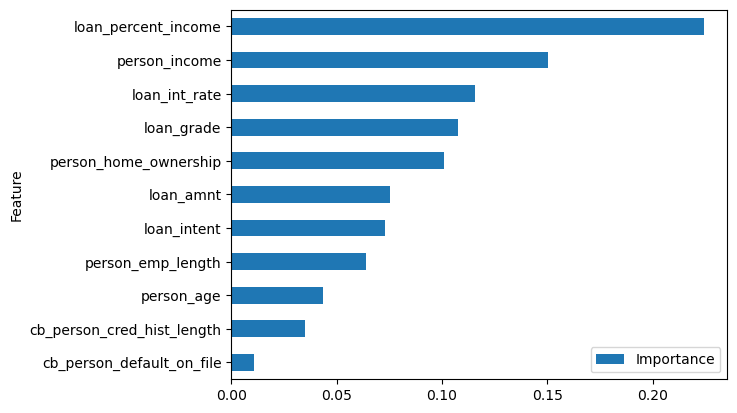

In [29]:
#FEATURE IMPORTANCE GRAPH
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [35]:
#SAVING THE MODEL
import joblib

joblib.dump(
    model,
    r"C:\Users\edara\OneDrive\Desktop\HorizonTechX_CreditScoringModel\model\credit_model.pkl"
)

['C:\\Users\\edara\\OneDrive\\Desktop\\HorizonTechX_CreditScoringModel\\model\\credit_model.pkl']

In [37]:
#HOW TO CHECK IT WORKED
import os

print(os.path.exists("../model/credit_model.pkl"))

True
